In [ ]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../')))
from matplotlib import pyplot as plt
# from quantpilot.features.technical_indicators import FeatureTechnicalIndicators
from quantpilot.features.feature_selection import plot_feature_importance, select_features
from quantpilot.features.ml_features import add_hmm_features, add_rolling_kmeans_cluster_feature, add_nlp_sentiment_score

In [2]:
# Load sample data
df = pd.read_csv('../../experimental/datasets/btc_data_with_target.csv', parse_dates=['datetime'], index_col='datetime')

df = add_nlp_sentiment_score(
    df,
    sentiment_file_path='../../experimental/datasets/bitcoin_sentiments_21_24.csv',
    datetime_col='datetime'
)

# Display data info
df.head()

,start_time,difficulty,start_time_estimated_leverage_ratio,estimated_leverage_ratio,start_time_addresses_count,addresses_count_active,addresses_count_receiver,addresses_count_sender,start_time_exchange_whale_ratio,exchange_whale_ratio,...,close,high,low,open,volume,start_time_open_interest,open_interest,future_return,target,sentiment
datetime,,,,,,,,,,,,,,,,,,,,,
2020-03-13 02:00:00,1584064800000,1.655292e+13,1584064800000,0.054695,1584064800000,48038,26544,26511,1584064800000,0.445868,...,5003.956097,5539.122307,3878.016146,4200.083158,166560.592230,1584064800000,7.575695e+07,0.063437,2,0
2020-03-13 03:00:00,1584068400000,1.655292e+13,1584068400000,0.054014,1584068400000,18207,12110,7846,1584068400000,0.701372,...,5321.391317,5673.675553,4963.723548,5002.358452,96918.928217,1584068400000,7.935403e+07,-0.088223,0,0
2020-03-13 04:00:00,1584072000000,1.655292e+13,1584072000000,0.055290,1584072000000,54478,37906,23715,1584072000000,0.396210,...,4851.922211,5336.407163,4716.028720,5308.371877,57978.769349,1584072000000,7.342217e+07,0.029847,2,0
2020-03-13 05:00:00,1584075600000,1.655292e+13,1584075600000,0.057333,1584075600000,55117,34953,27065,1584075600000,0.464358,...,4996.738882,5266.074097,4782.562902,4793.363609,62983.375418,1584075600000,7.863121e+07,0.048397,2,0
2020-03-13 06:00:00,1584079200000,1.655292e+13,1584079200000,0.060129,1584079200000,31961,18160,18053,1584079200000,0.660860,...,5238.567725,5270.315869,4876.518529,4996.574164,46180.527435,1584079200000,8.624586e+07,0.031998,2,0


In [3]:
# 2. Basic technical indicators
print("\n2. Adding basic technical indicators...")
new_df = df.copy()
# feature_technical = FeatureTechnicalIndicators(new_df, price_col='close')

# # Add individual technical indicators
# feature_technical.add_ema([5, 8, 13])
# feature_technical.add_sma([50, 200])
# feature_technical.add_rsi([14])
# feature_technical.add_macd(fast_window=12, slow_window=26, signal_window=9)
# feature_technical.add_price_change([1])
# feature_technical.add_bollinger_bands([20], num_std=2)

# # Add all features at once
# # feature_technical.add_all_features()

# # Show added features by comparing with original DataFrame
# added_features = list(set(new_df.columns) - set(df.columns))
# print(f"Added {len(added_features)} features: {', '.join(added_features)}")
new_df = new_df.dropna()
new_df.head()



2. Adding basic technical indicators...


,start_time,difficulty,start_time_estimated_leverage_ratio,estimated_leverage_ratio,start_time_addresses_count,addresses_count_active,addresses_count_receiver,addresses_count_sender,start_time_exchange_whale_ratio,exchange_whale_ratio,...,close,high,low,open,volume,start_time_open_interest,open_interest,future_return,target,sentiment
datetime,,,,,,,,,,,,,,,,,,,,,
2020-03-13 02:00:00,1584064800000,1.655292e+13,1584064800000,0.054695,1584064800000,48038,26544,26511,1584064800000,0.445868,...,5003.956097,5539.122307,3878.016146,4200.083158,166560.592230,1584064800000,7.575695e+07,0.063437,2,0
2020-03-13 03:00:00,1584068400000,1.655292e+13,1584068400000,0.054014,1584068400000,18207,12110,7846,1584068400000,0.701372,...,5321.391317,5673.675553,4963.723548,5002.358452,96918.928217,1584068400000,7.935403e+07,-0.088223,0,0
2020-03-13 04:00:00,1584072000000,1.655292e+13,1584072000000,0.055290,1584072000000,54478,37906,23715,1584072000000,0.396210,...,4851.922211,5336.407163,4716.028720,5308.371877,57978.769349,1584072000000,7.342217e+07,0.029847,2,0
2020-03-13 05:00:00,1584075600000,1.655292e+13,1584075600000,0.057333,1584075600000,55117,34953,27065,1584075600000,0.464358,...,4996.738882,5266.074097,4782.562902,4793.363609,62983.375418,1584075600000,7.863121e+07,0.048397,2,0
2020-03-13 06:00:00,1584079200000,1.655292e+13,1584079200000,0.060129,1584079200000,31961,18160,18053,1584079200000,0.660860,...,5238.567725,5270.315869,4876.518529,4996.574164,46180.527435,1584079200000,8.624586e+07,0.031998,2,0


In [31]:
print("\n3. Adding HMM & KMeans cluster features...")

# All the features except target
# feature_cols = list(set(new_df.columns) - set(['target']))
feature_cols = [
    "addresses_count_active",           # Reflects network activity
    "addresses_count_receiver",         # Indicates demand-side user activity
    "addresses_count_sender",           # Indicates spending / selling behavior
    # "blockreward_usd",                  # Incentivization for miners (can affect sell pressure)
    "fees_transaction_mean_usd",        # Reflects network congestion and user willingness to pay
    "miner_supply_ratio",               # Miner-held supply — key for sell pressure
    "exchange_supply_ratio",            # Reflects asset availability for trading on exchanges
    "transactions_count_inflow",        # Potential incoming pressure (supply side)
    "transactions_count_outflow",       # Potential withdrawals (holding / bullish behavior)
    # "tokens_transferred_mean",          # Reflects transaction volume per user
    "tokens_transferred_total",         # Overall market activity signal 
    "exchange_whale_ratio",             # Indicates large holders on exchanges
    "coinbase_premium_index_usdt_adjusted", # Reflects demand for BTC on Coinbase vs. other exchanges
    "coinbase_premium_gap_usdt_adjusted",   # Difference between Coinbase and Binance premiums
    "long_liquidations_usd",                # Indicates market sentiment and potential sell pressure
    "short_liquidations_usd"                # Indicates market sentiment and potential buy pressure
]

# Select features for HMM (Hidden Markov Model)
new_df = add_hmm_features(new_df, feature_cols, n_components=3, n_iter=2000, )

# Add KMeans cluster features using CNN (Rolling KMeans Clustering)
new_df = add_rolling_kmeans_cluster_feature(new_df, feature_cols, n_clusters=3)

new_df


3. Adding HMM & KMeans cluster features...


,start_time,difficulty,start_time_estimated_leverage_ratio,estimated_leverage_ratio,start_time_addresses_count,addresses_count_active,addresses_count_receiver,addresses_count_sender,start_time_exchange_whale_ratio,exchange_whale_ratio,...,low,open,volume,start_time_open_interest,open_interest,future_return,target,sentiment,hmm_state,kmeans_cluster
datetime,,,,,,,,,,,,,,,,,,,,,
2020-03-13 02:00:00,1584064800000,1.655292e+13,1584064800000,0.054695,1584064800000,-0.255297,-0.181550,-0.226777,1584064800000,-1.490020,...,3878.016146,4200.083158,166560.592230,1584064800000,7.575695e+07,0.063437,2,0,0,2
2020-03-13 03:00:00,1584068400000,1.655292e+13,1584068400000,0.054014,1584068400000,-1.826657,-1.507740,-1.658855,1584068400000,-0.134785,...,4963.723548,5002.358452,96918.928217,1584068400000,7.935403e+07,-0.088223,0,0,0,2
2020-03-13 04:00:00,1584072000000,1.655292e+13,1584072000000,0.055290,1584072000000,0.083933,0.862386,-0.441301,1584072000000,-1.753415,...,4716.028720,5308.371877,57978.769349,1584072000000,7.342217e+07,0.029847,2,0,0,2
2020-03-13 05:00:00,1584075600000,1.655292e+13,1584075600000,0.057333,1584075600000,0.117593,0.591066,-0.184271,1584075600000,-1.391950,...,4782.562902,4793.363609,62983.375418,1584075600000,7.863121e+07,0.048397,2,0,0,2
2020-03-13 06:00:00,1584079200000,1.655292e+13,1584079200000,0.060129,1584079200000,-1.102160,-0.951868,-0.875720,1584079200000,-0.349666,...,4876.518529,4996.574164,46180.527435,1584079200000,8.624586e+07,0.031998,2,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-31 18:00:00,1743444000000,1.137575e+14,1743444000000,0.162283,1743444000000,1.230835,0.912185,1.394046,1743444000000,0.636043,...,82725.931173,82732.416876,989.551559,1743444000000,7.737655e+09,-0.010128,0,0,1,1
2025-03-31 19:00:00,1743447600000,1.137575e+14,1743447600000,0.161615,1743447600000,0.330243,0.109433,0.576461,1743447600000,1.436468,...,82382.628052,83300.876330,1635.480392,1743447600000,7.628593e+09,-0.000035,1,0,1,1
2025-03-31 20:00:00,1743451200000,1.137575e+14,1743451200000,0.161152,1743451200000,0.964456,0.705088,1.154126,1743451200000,1.359096,...,82365.878186,82437.212737,719.056901,1743451200000,7.613252e+09,0.001304,2,0,1,1



Unique values in 'hmm_state' column:
hmm_state
1    18332
2    17709
0     8055
Name: count, dtype: int64
                   mean           std           min            max  count  \
hmm_state                                                                   
0          43686.903548  22578.161463   4449.246398  107872.962107   8055   
1          45563.941499  29824.815162   4816.678197  108258.766155  18332   
2          32934.778986  12363.659894  16122.745750   68631.802782  17709   

           duration_days  volatility  
hmm_state                             
0                   8055    0.516818  
1                  18332    0.654571  
2                  17709    0.375398  


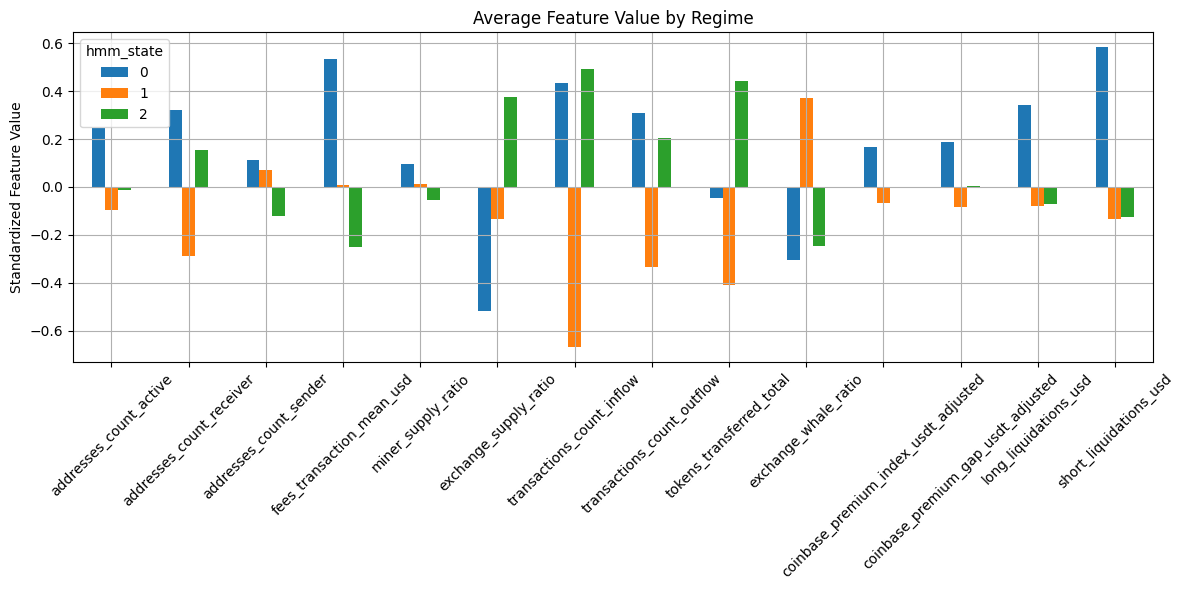

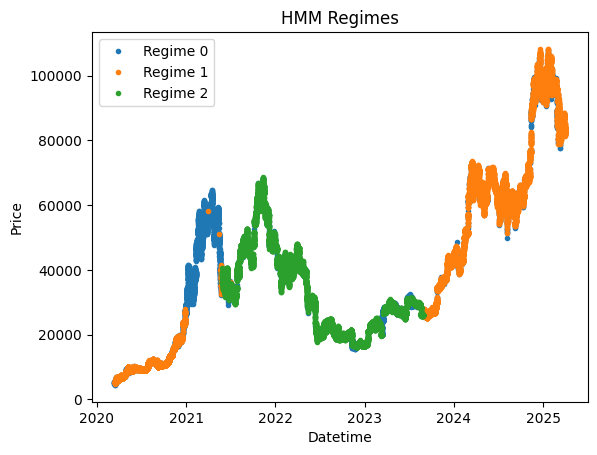

In [32]:
# find unique values in the 'hmm_state' column and their counts
unique_values = new_df['hmm_state'].value_counts()
print("\nUnique values in 'hmm_state' column:")
print(unique_values)

regime_stats = new_df.groupby('hmm_state')['close'].agg(['mean', 'std', 'min', 'max', 'count'])
regime_stats['duration_days'] = regime_stats['count']
regime_stats['volatility'] = regime_stats['std'] / regime_stats['mean']
print(regime_stats)

# Take mean of all features grouped by regime
hmm_feature_means = new_df.groupby('hmm_state')[feature_cols].mean()
hmm_feature_means.T.plot(kind='bar', figsize=(12,6))
plt.title("Average Feature Value by Regime")
plt.ylabel("Standardized Feature Value")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


# Plot Hidden Markov Model (HMM) regimes
for i in range(3):
    plt.plot(new_df[new_df['hmm_state'] == i].index,
                new_df[new_df['hmm_state'] == i]['close'], 
                '.',
                label=f"Regime {i}")
    plt.legend()
    
plt.title("HMM Regimes")
plt.xlabel("Datetime")
plt.ylabel("Price")   
plt.show()


Unique values in 'kmeans_cluster' column:
kmeans_cluster
1    23679
0    12902
2     7515
Name: count, dtype: int64
                        mean           std           min            max  \
kmeans_cluster                                                            
0               37897.403359  15293.807330   5295.855848  107872.962107   
1               49316.859614  24195.297015  15697.786366  108258.766155   
2               15128.671691  11760.591027   4449.246398   74351.521813   

                count  duration_days  volatility  
kmeans_cluster                                    
0               12902          12902    0.403558  
1               23679          23679    0.490609  
2                7515           7515    0.777371  


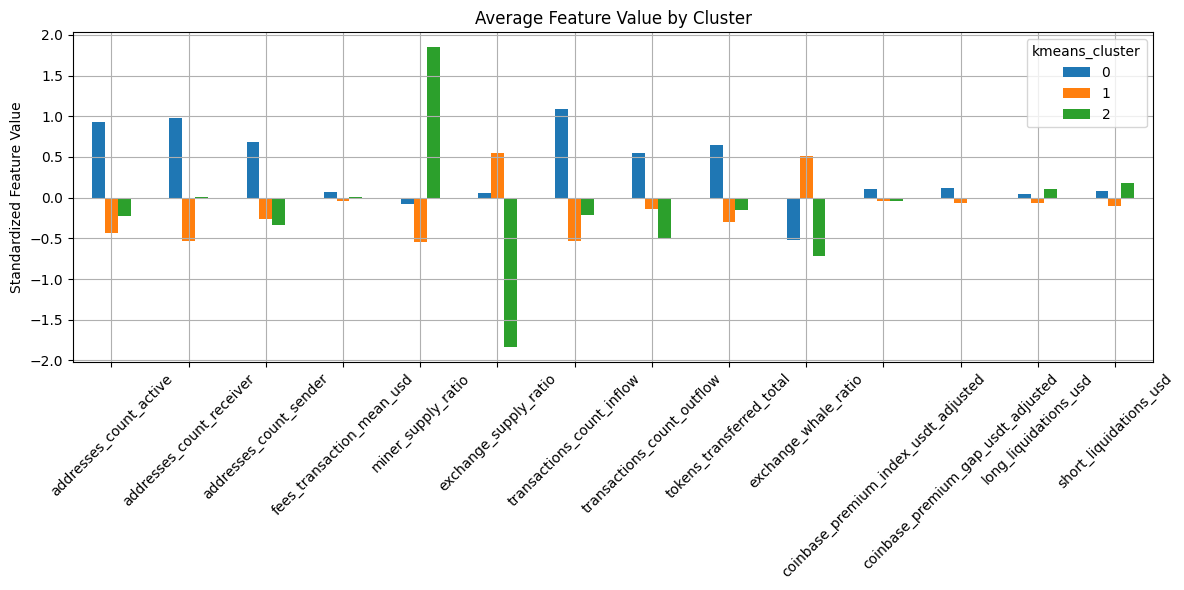

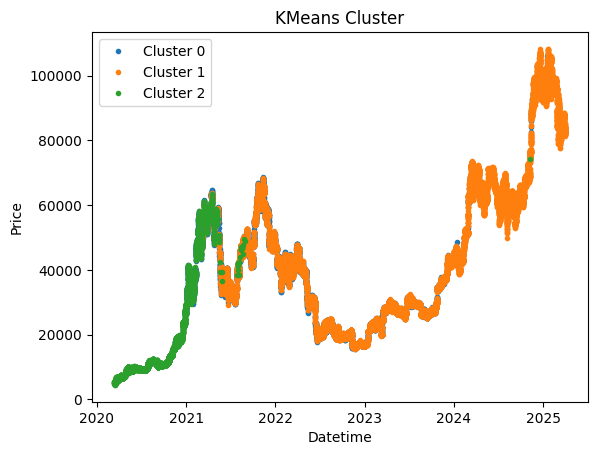

In [33]:
# Plot KMeans clusters
unique_values = new_df['kmeans_cluster'].value_counts()
print("\nUnique values in 'kmeans_cluster' column:")
print(unique_values)

cluster_stats = new_df.groupby('kmeans_cluster')['close'].agg(['mean', 'std', 'min', 'max', 'count'])
cluster_stats['duration_days'] = cluster_stats['count']
cluster_stats['volatility'] = cluster_stats['std'] / cluster_stats['mean']
print(cluster_stats)
# Take mean of all features grouped by cluster
kmeans_feature_means = new_df.groupby('kmeans_cluster')[feature_cols].mean()
kmeans_feature_means.T.plot(kind='bar', figsize=(12,6))
plt.title("Average Feature Value by Cluster")
plt.ylabel("Standardized Feature Value")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

for i in range(3):
    plt.plot(new_df[new_df['kmeans_cluster'] == i].index,
                new_df[new_df['kmeans_cluster'] == i]['close'], 
                '.',
                label=f"Cluster {i}")
    plt.legend()
    
plt.title("KMeans Cluster")
plt.xlabel("Datetime")
plt.ylabel("Price")   
    
plt.show()


4. Feature selection...

Top Features:
                             feature  importance
                    taker_sell_ratio    0.056899
                     taker_buy_ratio    0.056899
                taker_buy_sell_ratio    0.056261
coinbase_premium_index_usdt_adjusted    0.045266
  coinbase_premium_gap_usdt_adjusted    0.034479
              addresses_count_active    0.017555
              addresses_count_sender    0.017535
                         blockreward    0.016074
                   long_liquidations    0.014452
            addresses_count_receiver    0.013599
             tokens_transferred_mean    0.013381
                           hmm_state    0.011453
                   taker_sell_volume    0.010776
                     blockreward_usd    0.009748
            tokens_transferred_total    0.009133
                  short_liquidations    0.008818
              short_liquidations_usd    0.007801
               long_liquidations_usd    0.007127
           fees_transaction_m

,taker_sell_ratio,taker_buy_ratio,taker_buy_sell_ratio,coinbase_premium_index_usdt_adjusted,coinbase_premium_gap_usdt_adjusted,addresses_count_active,addresses_count_sender,blockreward,long_liquidations,addresses_count_receiver,...,hmm_state,taker_sell_volume,blockreward_usd,tokens_transferred_total,short_liquidations,short_liquidations_usd,long_liquidations_usd,fees_transaction_mean_usd,exchange_supply_ratio,close
datetime,,,,,,,,,,,,,,,,,,,,,
2020-03-13 02:00:00,0.496592,0.503408,1.013725,11.499028,1.539566,-0.255297,-0.226777,77.841484,2366.709000,-0.181550,...,0,1.998601e+08,-1.192379,0.238229,2083.077000,4.309261,1.728757,-0.361968,-1.959557,5003.956097
2020-03-13 03:00:00,0.485980,0.514020,1.057699,4.245331,0.594184,-1.826657,-1.658855,26.791044,1075.036000,-1.507740,...,0,1.537000e+08,-1.406662,-0.180939,823.359000,1.857249,0.898996,-0.270945,-1.966445,5321.391317
2020-03-13 04:00:00,0.522829,0.477171,0.912672,-0.316242,-0.061037,0.083933,-0.441301,78.638468,1297.364000,0.862386,...,0,1.009769e+08,-1.104104,0.777109,128.929000,0.087969,1.039788,-0.326806,-1.989477,4851.922211
2020-03-13 05:00:00,0.505362,0.494638,0.978780,-0.898281,-0.145514,0.117593,-0.184271,78.031384,1626.762000,0.591066,...,0,1.073788e+08,-1.109809,0.284504,328.634000,0.573779,1.369816,-0.339409,-1.981981,4996.738882
2020-03-13 06:00:00,0.493174,0.506826,1.027683,1.616944,0.222220,-1.102160,-0.875720,52.144150,1085.844000,-0.951868,...,0,7.877188e+07,-1.265196,-0.233787,214.322000,0.304542,0.875308,-0.341044,-1.988446,5238.567725
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-31 18:00:00,0.488277,0.511723,1.048020,-0.050360,-0.076080,1.230835,1.394046,22.152889,0.097000,0.912185,...,1,3.424566e+08,0.595742,-0.480927,3.475084,-0.076377,-0.106997,-0.345368,0.454438,83287.446732
2025-03-31 19:00:00,0.531443,0.468557,0.881669,-0.043625,-0.059583,0.330243,0.576461,19.119721,7.523869,0.109433,...,1,3.754510e+08,0.293283,-0.533641,0.002000,-0.216426,0.004348,-0.265144,0.454988,82443.899978
2025-03-31 20:00:00,0.469972,0.530028,1.127787,-0.028057,-0.022675,0.964456,1.154126,31.509539,0.464244,0.705088,...,1,2.203566e+08,1.487885,-0.155463,0.283000,-0.205161,-0.101533,-0.343491,0.459511,82441.035723


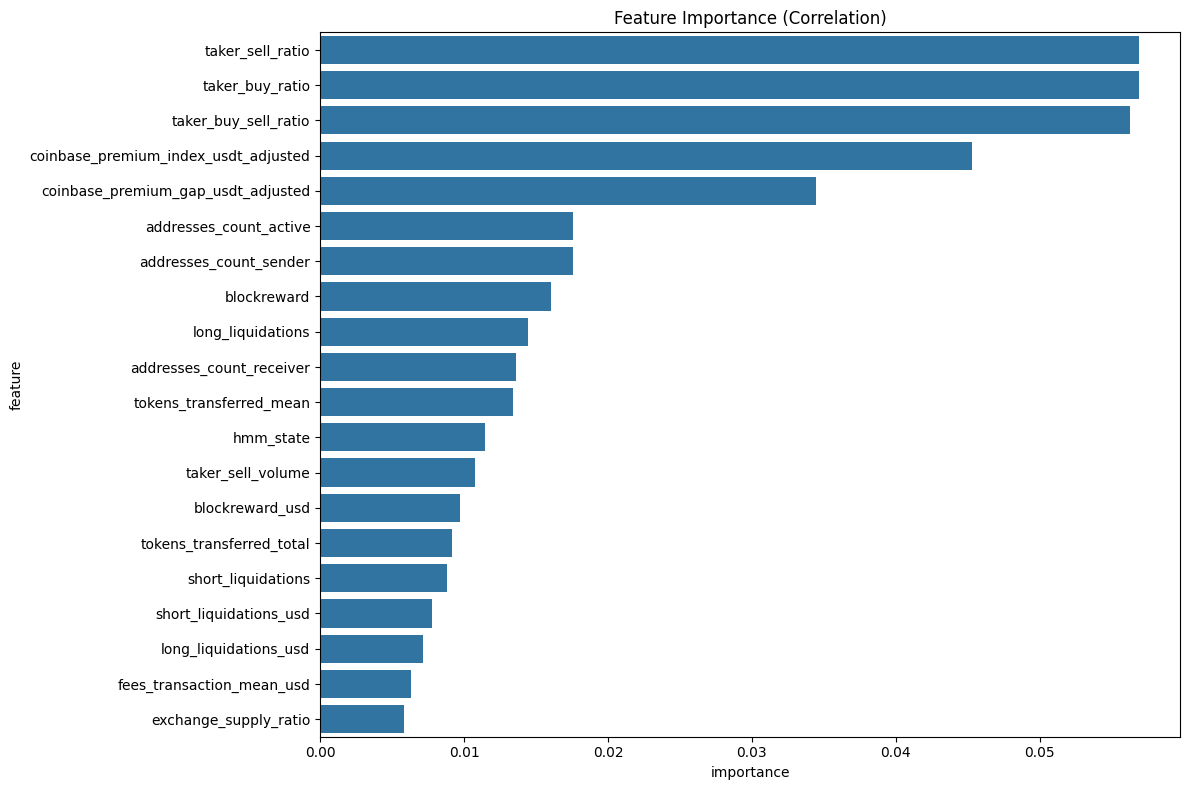

In [37]:
# 4. Feature selection
### NOTE: the target column should be the one you want to predict, i.e., 'buy' or 'sell' signal
print("\n4. Feature selection...") 
new_df2 = new_df.copy()

target_col = 'target'
X = new_df2.drop(columns=[target_col, 'future_return'])
top10_all = plot_feature_importance(new_df2, target_col=target_col, feature_cols=list(X.columns), top_n=20, save_img_path='feature_importance_all.png', method='correlation')
print(f"Top 20 features (all): {top10_all}")

# Select features based on correlation
new_df2 = select_features(new_df2, features=top10_all + ['close'])
new_df2

In [36]:
# Save the new DataFrame to a CSV file
new_df.to_csv('../../experimental/datasets/btc_data_with_target_latest_v2.csv', index=True)